# Phase-2 Sweep Analysis

Load all 27 phase-2 cell evaluations into a DataFrame; filter, sort, plot.

Source: `02_rl_control/logs_cluster/logs/<algo>/phase2/cell_*/evaluation_metrics.json` + matching `train_config.json`.

Phase-1 baselines (best seed per algo, lowest RMSE):
- PPO: seed 3 — RMSE 3.16, NOx 5.57 g, dSOC +0.299
- SAC: seed 3 — RMSE 3.11, NOx 48.94 g, dSOC +0.299
- TD3: seed 1 — RMSE 3.52, NOx 73.42 g, dSOC +0.300

In [1]:
import os, sys, json, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = os.getcwd()
if os.path.basename(current_dir) != "hyperparameter_search":
    current_dir = os.path.join(current_dir, "02_rl_control", "hyperparameter_search")
sys.path.insert(0, current_dir)
from collect_phase2_results import collect

RL_CONTROL_DIR = os.path.dirname(current_dir)
P2_LOGS = os.path.join(RL_CONTROL_DIR, "logs_cluster", "logs")

PHASE1_BASELINE = {
    "ppo": {"seed": 3, "rmse": 3.163, "nox_g": 5.57, "delta_soc": 0.2992},
    "sac": {"seed": 3, "rmse": 3.106, "nox_g": 48.94, "delta_soc": 0.2987},
    "td3": {"seed": 1, "rmse": 3.515, "nox_g": 73.42, "delta_soc": 0.2999},
}
PHASE1_BASELINE

{'ppo': {'seed': 3, 'rmse': 3.163, 'nox_g': 5.57, 'delta_soc': 0.2992},
 'sac': {'seed': 3, 'rmse': 3.106, 'nox_g': 48.94, 'delta_soc': 0.2987},
 'td3': {'seed': 1, 'rmse': 3.515, 'nox_g': 73.42, 'delta_soc': 0.2999}}

In [2]:
df = collect(P2_LOGS)
df = df.sort_values(["algo", "cell_id"]).reset_index(drop=True)

# Append phase-1 baseline columns and deltas vs baseline
df["p1_rmse"] = df["algo"].map(lambda a: PHASE1_BASELINE[a]["rmse"])
df["p1_nox"]  = df["algo"].map(lambda a: PHASE1_BASELINE[a]["nox_g"])
df["p1_dsoc"] = df["algo"].map(lambda a: PHASE1_BASELINE[a]["delta_soc"])
df["drmse_pct"] = (df["rmse_speed_kmph"] - df["p1_rmse"]) / df["p1_rmse"] * 100
df["dnox_pct"]  = (df["total_nox_g"]    - df["p1_nox"])  / df["p1_nox"]  * 100
df["abs_dsoc"]  = df["delta_soc"].abs()

csv_out = os.path.join(RL_CONTROL_DIR, "logs_cluster", "phase2_results.csv")
df.to_csv(csv_out, index=False)
print(f"Saved {len(df)} rows -> {csv_out}")
df.head()

Saved 27 rows -> /Users/niklaslongschiefelbein/local_documents/THESIS/code/rl_emission_reduction/02_rl_control/logs_cluster/phase2_results.csv


,algo,cell_id,cell_dir,w_emission,w_soc_squared,phase1_best_seed,total_timesteps,training_duration_hms,total_reward,rmse_speed_kmph,...,delta_soc,max_abs_soc_drift,rms_soc_drift,abs_path,p1_rmse,p1_nox,p1_dsoc,drmse_pct,dnox_pct,abs_dsoc
0,ppo,0,cell_00_we0.25_wsq50,0.25,50.0,3,4000000,6:03:05,3549.088623,3.218872,...,0.000894,0.017952,0.007835,/Users/niklaslongschiefelbein/local_documents/...,3.163,5.57,0.2992,1.766420,104.765347,0.000894
1,ppo,1,cell_01_we0.25_wsq150,0.25,150.0,3,4000000,11:50:55,3552.172852,3.268522,...,-0.028637,0.028637,0.013642,/Users/niklaslongschiefelbein/local_documents/...,3.163,5.57,0.2992,3.336149,22.069970,0.028637
2,ppo,2,cell_02_we0.25_wsq400,0.25,400.0,3,4000000,6:09:10,3537.012695,3.375077,...,-0.035708,0.051518,0.028791,/Users/niklaslongschiefelbein/local_documents/...,3.163,5.57,0.2992,6.704928,-0.443130,0.035708
3,ppo,3,cell_03_we0.5_wsq50,0.50,50.0,3,4000000,11:49:34,3552.462158,3.176561,...,-0.013893,0.023367,0.012115,/Users/niklaslongschiefelbein/local_documents/...,3.163,5.57,0.2992,0.428729,14.254515,0.013893
4,ppo,4,cell_04_we0.5_wsq150,0.50,150.0,3,4000000,11:42:42,3549.898682,3.200171,...,-0.020838,0.032671,0.016793,/Users/niklaslongschiefelbein/local_documents/...,3.163,5.57,0.2992,1.175186,-3.663630,0.020838


## Full results table (sortable)

In [3]:
show_cols = ["algo", "cell_id", "w_emission", "w_soc_squared",
             "rmse_speed_kmph", "total_nox_g", "delta_soc",
             "max_abs_soc_drift", "rms_soc_drift",
             "drmse_pct", "dnox_pct"]
df[show_cols].round(3)

,algo,cell_id,w_emission,w_soc_squared,rmse_speed_kmph,total_nox_g,delta_soc,max_abs_soc_drift,rms_soc_drift,drmse_pct,dnox_pct
0,ppo,0,0.25,50.0,3.219,11.405,0.001,0.018,0.008,1.766,104.765
1,ppo,1,0.25,150.0,3.269,6.799,-0.029,0.029,0.014,3.336,22.070
2,ppo,2,0.25,400.0,3.375,5.545,-0.036,0.052,0.029,6.705,-0.443
3,ppo,3,0.50,50.0,3.177,6.364,-0.014,0.023,0.012,0.429,14.255
4,ppo,4,0.50,150.0,3.200,5.366,-0.021,0.033,0.017,1.175,-3.664
5,ppo,5,0.50,400.0,3.134,5.461,-0.029,0.038,0.022,-0.914,-1.951
6,ppo,6,1.00,50.0,3.115,10.389,-0.012,0.051,0.025,-1.514,86.514
7,ppo,7,1.00,150.0,3.267,4.757,0.002,0.019,0.009,3.287,-14.590
8,ppo,8,1.00,400.0,3.070,9.513,-0.033,0.047,0.024,-2.954,70.786
9,sac,0,0.25,50.0,3.173,3.405,-0.006,0.015,0.006,2.172,-93.042


## Filter: RMSE ≤ 5 km/h, minimize NOx
Change `RMSE_THR` / `SOC_THR` and re-run cells to explore.

In [4]:
RMSE_THR = 5.0
SOC_THR  = None   # set e.g. 0.1 to also constrain max_abs_soc_drift
TOP_N    = 5

f = df[df["rmse_speed_kmph"] <= RMSE_THR]
if SOC_THR is not None:
    f = f[f["max_abs_soc_drift"] <= SOC_THR]

for algo in ["ppo", "sac", "td3"]:
    sub = f[f["algo"] == algo].sort_values("total_nox_g").head(TOP_N)
    print(f"=== {algo.upper()} ({len(f[f['algo']==algo])} pass) ===")
    print(sub[show_cols].round(3).to_string(index=False))
    print()

=== PPO (9 pass) ===
algo  cell_id  w_emission  w_soc_squared  rmse_speed_kmph  total_nox_g  delta_soc  max_abs_soc_drift  rms_soc_drift  drmse_pct  dnox_pct
 ppo        7        1.00          150.0            3.267        4.757      0.002              0.019          0.009      3.287   -14.590
 ppo        4        0.50          150.0            3.200        5.366     -0.021              0.033          0.017      1.175    -3.664
 ppo        5        0.50          400.0            3.134        5.461     -0.029              0.038          0.022     -0.914    -1.951
 ppo        2        0.25          400.0            3.375        5.545     -0.036              0.052          0.029      6.705    -0.443
 ppo        3        0.50           50.0            3.177        6.364     -0.014              0.023          0.012      0.429    14.255

=== SAC (8 pass) ===
algo  cell_id  w_emission  w_soc_squared  rmse_speed_kmph  total_nox_g  delta_soc  max_abs_soc_drift  rms_soc_drift  drmse_pct  dnox_pc

## Pareto front per algo (NOx vs RMSE, marker size = max|dSOC|)

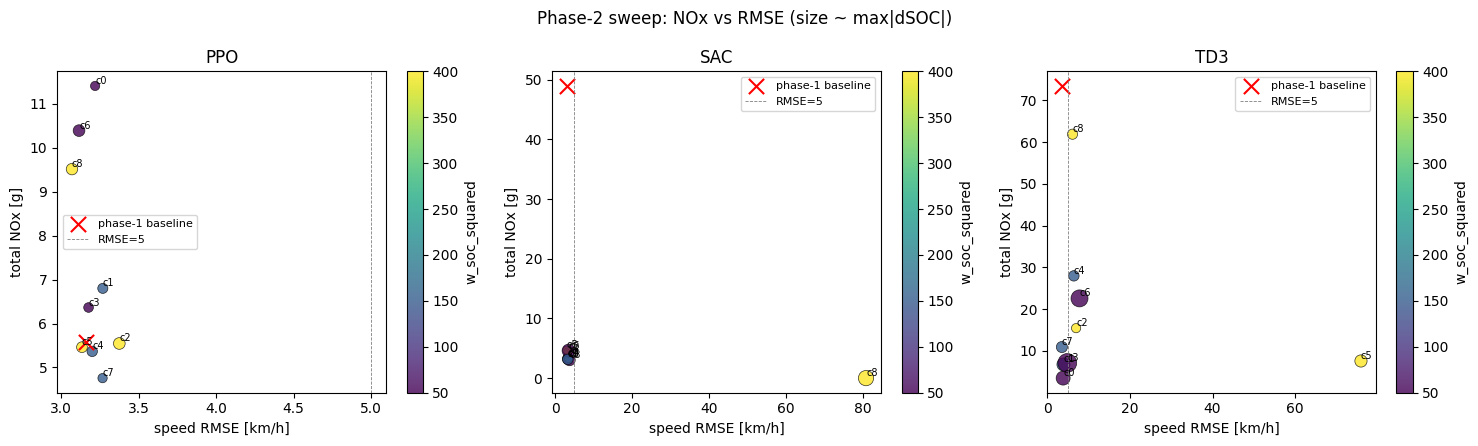

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, algo in zip(axes, ["ppo", "sac", "td3"]):
    sub = df[df["algo"] == algo]
    sizes = 30 + sub["max_abs_soc_drift"] * 800
    sc = ax.scatter(sub["rmse_speed_kmph"], sub["total_nox_g"], s=sizes,
                    c=sub["w_soc_squared"], cmap="viridis", alpha=0.8,
                    edgecolor="k", linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(f"c{int(r['cell_id'])}", (r['rmse_speed_kmph'], r['total_nox_g']),
                    fontsize=7, ha="left", va="bottom")
    # phase-1 baseline
    p1 = PHASE1_BASELINE[algo]
    ax.scatter([p1["rmse"]], [p1["nox_g"]], marker="x", s=120,
               c="red", label="phase-1 baseline")
    ax.axvline(5.0, ls="--", c="gray", lw=0.6, label="RMSE=5")
    ax.set_xlabel("speed RMSE [km/h]")
    ax.set_ylabel("total NOx [g]")
    ax.set_title(algo.upper())
    ax.legend(fontsize=8, loc="best")
    plt.colorbar(sc, ax=ax, label="w_soc_squared")
plt.suptitle("Phase-2 sweep: NOx vs RMSE (size ~ max|dSOC|)")
plt.tight_layout()
plt.show()

## SOC drift vs weights

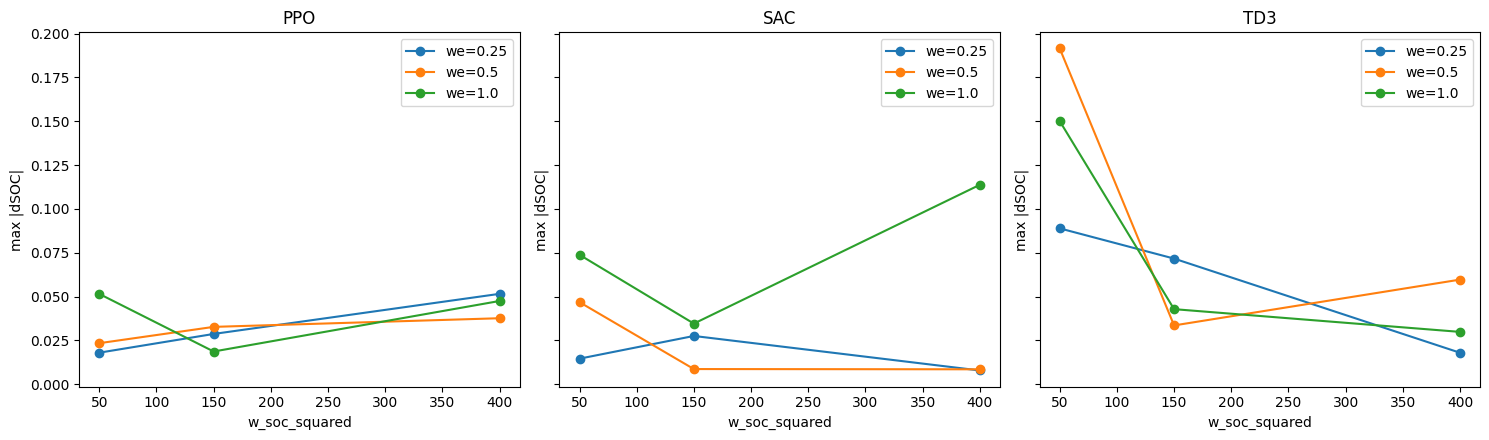

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, algo in zip(axes, ["ppo", "sac", "td3"]):
    sub = df[df["algo"] == algo]
    for we, color in zip([0.25, 0.5, 1.0], ["C0", "C1", "C2"]):
        s = sub[sub["w_emission"] == we].sort_values("w_soc_squared")
        ax.plot(s["w_soc_squared"], s["max_abs_soc_drift"], "o-",
                label=f"we={we}", color=color)
    ax.set_xlabel("w_soc_squared")
    ax.set_ylabel("max |dSOC|")
    ax.set_title(algo.upper())
    ax.legend()
plt.tight_layout()
plt.show()

## Quick lookup: winning cell directory per algo

In [7]:
for algo in ["ppo", "sac", "td3"]:
    f = df[(df["algo"]==algo) & (df["rmse_speed_kmph"]<=5.0)]
    if f.empty:
        print(f"{algo.upper()}: no cell <= 5.0 RMSE")
        continue
    w = f.sort_values("total_nox_g").iloc[0]
    print(f"{algo.upper()}: cell {int(w['cell_id'])} we={w['w_emission']} wsq={w['w_soc_squared']}")
    print(f"  rmse={w['rmse_speed_kmph']:.3f} nox={w['total_nox_g']:.3f}g max|dSOC|={w['max_abs_soc_drift']:.4f}")
    print(f"  dir={w['abs_path']}\n")

PPO: cell 7 we=1.0 wsq=150.0
  rmse=3.267 nox=4.757g max|dSOC|=0.0186
  dir=/Users/niklaslongschiefelbein/local_documents/THESIS/code/rl_emission_reduction/02_rl_control/logs_cluster/logs/ppo/phase2/cell_07_we1_wsq150

SAC: cell 3 we=0.5 wsq=50.0
  rmse=3.742 nox=3.028g max|dSOC|=0.0468
  dir=/Users/niklaslongschiefelbein/local_documents/THESIS/code/rl_emission_reduction/02_rl_control/logs_cluster/logs/sac/phase2/cell_03_we0.5_wsq50

TD3: cell 0 we=0.25 wsq=50.0
  rmse=3.791 nox=3.508g max|dSOC|=0.0889
  dir=/Users/niklaslongschiefelbein/local_documents/THESIS/code/rl_emission_reduction/02_rl_control/logs_cluster/logs/td3/phase2/cell_00_we0.25_wsq50

